# 🧪 9개 모델 비교 테스트 (Before/After 분석)

**목적**: Baseline(kor_unsmile) 대비 Fine-tuned 모델들의 성능 개선 확인

| 구분 | 모델 |
|------|------|
| Baseline | smilegate-ai/kor_unsmile |
| LoRA v1 | Game KcELECTRA, Tutorial kcbert |
| LoRA v2 | Game KcELECTRA (+ 게임데이터), Tutorial kcbert (+ 게임데이터) |
| Full v1 | Game KcELECTRA, Tutorial kcbert |
| Full v2 | Game KcELECTRA (+ 게임데이터), Tutorial kcbert (+ 게임데이터) |

In [1]:
# 1. 환경 설정
import os, torch, pandas as pd, numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import precision_recall_fscore_support, label_ranking_average_precision_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

🖥️ Device: cuda
   GPU: NVIDIA L40S


In [2]:
# 2. 설정
MAX_LENGTH = 128
LABEL_NAMES = ["여성/가족", "남성", "성소수자", "인종/국적", "연령", "지역", "종교", "기타 혐오", "악플/욕설", "clean"]

# 베이스 토크나이저 (Fine-tuned 모델은 토크나이저가 저장되지 않으므로 베이스 모델 사용)
BASE_TOKENIZERS = {
    'kcelectra': 'beomi/KcELECTRA-base-v2022',
    'kcbert': 'beomi/kcbert-base',
    'unsmile': 'smilegate-ai/kor_unsmile'
}

# 모델 설정: (model_path, tokenizer_key)
MODELS = {
    "Baseline (kor_unsmile)": ("smilegate-ai/kor_unsmile", "unsmile"),
    "Full v1 Game": ("../4_2_Full_Fine_Tuning/v1_corrected_only/output/full_game_kcelectra/best_model", "kcelectra"),
    "Full v1 Tutorial": ("../4_2_Full_Fine_Tuning/v1_corrected_only/output/full_tutorial_kcbert/best_model", "kcbert"),
    "Full v2 Game": ("../4_2_Full_Fine_Tuning/v2_corrected_plus_collected/output/full_game_kcelectra_v2/best_model", "kcelectra"),
    "Full v2 Tutorial": ("../4_2_Full_Fine_Tuning/v2_corrected_plus_collected/output/full_tutorial_kcbert_v2/best_model", "kcbert"),
    "LoRA v1 Game": ("../4_1_LoRA_Fine_Tuning/v1_corrected_only/output/lora_game_kcelectra/merged_model", "kcelectra"),
    "LoRA v1 Tutorial": ("../4_1_LoRA_Fine_Tuning/v1_corrected_only/output/lora_tutorial_kcbert/merged_model", "kcbert"),
    "LoRA v2 Game": ("../4_1_LoRA_Fine_Tuning/v2_corrected_plus_collected/output/lora_game_kcelectra_v2/merged_model", "kcelectra"),
    "LoRA v2 Tutorial": ("../4_1_LoRA_Fine_Tuning/v2_corrected_plus_collected/output/lora_tutorial_kcbert_v2/merged_model", "kcbert"),
}

print(f"📋 테스트할 모델: {len(MODELS)}개")
for name, (path, tok) in MODELS.items():
    print(f"   - {name} (tokenizer: {tok})")

📋 테스트할 모델: 9개
   - Baseline (kor_unsmile) (tokenizer: unsmile)
   - Full v1 Game (tokenizer: kcelectra)
   - Full v1 Tutorial (tokenizer: kcbert)
   - Full v2 Game (tokenizer: kcelectra)
   - Full v2 Tutorial (tokenizer: kcbert)
   - LoRA v1 Game (tokenizer: kcelectra)
   - LoRA v1 Tutorial (tokenizer: kcbert)
   - LoRA v2 Game (tokenizer: kcelectra)
   - LoRA v2 Tutorial (tokenizer: kcbert)


In [3]:
# 3. 테스트 데이터 로드
test_df = pd.read_csv("./data/game_test.tsv", sep='\t')

# 숫자 변환
for col in LABEL_NAMES:
    test_df[col] = pd.to_numeric(test_df[col], errors='coerce').fillna(0).astype(int)

print(f"✅ 테스트 데이터: {len(test_df)}건")
print(f"   - 악플/욕설: {test_df['악플/욕설'].sum()}건 ({test_df['악플/욕설'].sum()/len(test_df)*100:.1f}%)")
print(f"   - clean: {test_df['clean'].sum()}건 ({test_df['clean'].sum()/len(test_df)*100:.1f}%)")

# 샘플 확인
print("\n📝 샘플 데이터:")
test_df[['문장', '악플/욕설', 'clean']].head(10)

✅ 테스트 데이터: 187건
   - 악플/욕설: 116건 (62.0%)
   - clean: 71건 (38.0%)

📝 샘플 데이터:


,문장,악플/욕설,clean
0,아 진짜 못해,1,0
1,아니 이거 아야 스톱 무빙으로 한 번 빼 스톱 코드라 킬을 발랐어,0,1
2,그냥 내가 다 해줄게 기다려 아니 아까 내가 온 것처럼 오면 되잖아,0,1
3,진짜 피지컬 레전드 아니 이거 전략에 당했어 계획살인이야 0,1,0
4,아니면 그 앞에서 멈추던가 지금부터 죽으면 다 모여서 한번에 가야돼,0,1
5,난 게임 잘해 문열고 들어가,0,1
6,제발 버텨 미친,1,0
7,그냥 아니야 그쪽으로 말고 오른쪽으로 자기들끼리 지금 쓰고 서버 하면 돼 오른쪽으로 하죠,0,1
8,아니 나한테 못 치면 어떡해,0,1
9,아니 바싹 붙지 말라니까,0,1


In [4]:
# 4. 평가 함수 (상세 결과 포함)
def evaluate_model(model_name, model_path, tokenizer_key, test_df):
    """모델 평가 - 상세 예측 결과 반환"""
    print(f"\n{'='*60}")
    print(f"🔄 평가 중: {model_name}")
    print(f"   모델: {model_path}")
    print(f"   토크나이저: {BASE_TOKENIZERS[tokenizer_key]}")
    
    try:
        # 토크나이저는 베이스 모델에서 로드
        tokenizer = AutoTokenizer.from_pretrained(BASE_TOKENIZERS[tokenizer_key])
        model = AutoModelForSequenceClassification.from_pretrained(model_path).to(DEVICE)
        model.eval()
        
        all_preds = []
        all_probs = []
        all_labels = []
        
        with torch.no_grad():
            for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc=model_name):
                inputs = tokenizer(
                    str(row['문장']), 
                    padding='max_length', 
                    truncation=True, 
                    max_length=MAX_LENGTH,
                    return_tensors='pt'
                ).to(DEVICE)
                
                outputs = model(**inputs)
                probs = torch.sigmoid(outputs.logits).cpu().numpy()[0]
                preds = (probs > 0.5).astype(int)
                
                all_probs.append(probs)
                all_preds.append(preds)
                all_labels.append([int(row[col]) for col in LABEL_NAMES])
        
        all_probs = np.array(all_probs)
        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        
        # 메트릭 계산
        lrap = label_ranking_average_precision_score(all_labels, all_probs)
        
        # 악플/욕설 (index 8)
        abuse_p, abuse_r, abuse_f1, _ = precision_recall_fscore_support(
            all_labels[:,8], all_preds[:,8], average='binary', zero_division=0
        )
        
        # Clean (index 9)
        clean_p, clean_r, clean_f1, _ = precision_recall_fscore_support(
            all_labels[:,9], all_preds[:,9], average='binary', zero_division=0
        )
        
        # Confusion Matrix
        abuse_cm = confusion_matrix(all_labels[:,8], all_preds[:,8])
        clean_cm = confusion_matrix(all_labels[:,9], all_preds[:,9])
        
        print(f"   ✅ LRAP: {lrap:.4f}")
        print(f"   ✅ Abuse - P: {abuse_p:.4f}, R: {abuse_r:.4f}, F1: {abuse_f1:.4f}")
        print(f"   ✅ Clean - P: {clean_p:.4f}, R: {clean_r:.4f}, F1: {clean_f1:.4f}")
        
        # 메모리 정리
        del model, tokenizer
        torch.cuda.empty_cache()
        
        return {
            'model': model_name,
            'lrap': round(lrap, 4),
            'abuse_precision': round(abuse_p, 4),
            'abuse_recall': round(abuse_r, 4),
            'abuse_f1': round(abuse_f1, 4),
            'clean_precision': round(clean_p, 4),
            'clean_recall': round(clean_r, 4),
            'clean_f1': round(clean_f1, 4),
            'abuse_cm': abuse_cm,
            'clean_cm': clean_cm,
            'predictions': all_preds,
            'probabilities': all_probs
        }
    
    except Exception as e:
        print(f"   ❌ 오류: {e}")
        return {'model': model_name, 'error': str(e)}

In [5]:
# 5. 모든 모델 평가 실행
results = []
detailed_results = {}

for model_name, (model_path, tokenizer_key) in MODELS.items():
    result = evaluate_model(model_name, model_path, tokenizer_key, test_df)
    results.append(result)
    detailed_results[model_name] = result

print("\n" + "="*60)
print("✅ 모든 모델 평가 완료!")


🔄 평가 중: Baseline (kor_unsmile)
   모델: smilegate-ai/kor_unsmile
   토크나이저: smilegate-ai/kor_unsmile


Baseline (kor_unsmile):   0%|          | 0/187 [00:00<?, ?it/s]

   ✅ LRAP: 0.8868
   ✅ Abuse - P: 0.9740, R: 0.6466, F1: 0.7772
   ✅ Clean - P: 0.6449, R: 0.9718, F1: 0.7753

🔄 평가 중: Full v1 Game
   모델: ../4_2_Full_Fine_Tuning/v1_corrected_only/output/full_game_kcelectra/best_model
   토크나이저: beomi/KcELECTRA-base-v2022


Full v1 Game:   0%|          | 0/187 [00:00<?, ?it/s]

   ✅ LRAP: 0.8966
   ✅ Abuse - P: 0.9247, R: 0.7414, F1: 0.8230
   ✅ Clean - P: 0.6774, R: 0.8873, F1: 0.7683

🔄 평가 중: Full v1 Tutorial
   모델: ../4_2_Full_Fine_Tuning/v1_corrected_only/output/full_tutorial_kcbert/best_model
   토크나이저: beomi/kcbert-base


...

   ✅ LRAP: 0.8984
   ✅ Abuse - P: 0.9348, R: 0.7414, F1: 0.8269
   ✅ Clean - P: 0.6915, R: 0.9155, F1: 0.7879

🔄 평가 중: LoRA v2 Game
   모델: ../4_1_LoRA_Fine_Tuning/v2_corrected_plus_collected/output/lora_game_kcelectra_v2/merged_model
   토크나이저: beomi/KcELECTRA-base-v2022


LoRA v2 Game:   0%|          | 0/187 [00:00<?, ?it/s]

   ✅ LRAP: 0.9207
   ✅ Abuse - P: 0.8793, R: 0.8793, F1: 0.8793
   ✅ Clean - P: 0.7867, R: 0.8310, F1: 0.8082

🔄 평가 중: LoRA v2 Tutorial
   모델: ../4_1_LoRA_Fine_Tuning/v2_corrected_plus_collected/output/lora_tutorial_kcbert_v2/merged_model
   토크나이저: beomi/kcbert-base


LoRA v2 Tutorial:   0%|          | 0/187 [00:00<?, ?it/s]

   ✅ LRAP: 0.9244
   ✅ Abuse - P: 0.8947, R: 0.8793, F1: 0.8870
   ✅ Clean - P: 0.8000, R: 0.8451, F1: 0.8219

✅ 모든 모델 평가 완료!


In [6]:
# 6. 결과 DataFrame 생성
cols = ['model', 'lrap', 'abuse_precision', 'abuse_recall', 'abuse_f1', 
        'clean_precision', 'clean_recall', 'clean_f1']
results_df = pd.DataFrame([{k: r.get(k) for k in cols} for r in results if 'error' not in r])
results_df = results_df.sort_values('abuse_recall', ascending=False).reset_index(drop=True)

print("📊 전체 결과 (Abuse Recall 기준 정렬)")
results_df

📊 전체 결과 (Abuse Recall 기준 정렬)


,model,lrap,abuse_precision,abuse_recall,abuse_f1,clean_precision,clean_recall,clean_f1
0,Full v2 Tutorial,0.9434,0.9358,0.8793,0.9067,0.8442,0.9155,0.8784
1,LoRA v2 Game,0.9207,0.8793,0.8793,0.8793,0.7867,0.8310,0.8082
2,LoRA v2 Tutorial,0.9244,0.8947,0.8793,0.8870,0.8000,0.8451,0.8219
3,Full v2 Game,0.9296,0.9099,0.8707,0.8899,0.8026,0.8592,0.8299
4,LoRA v1 Game,0.8917,0.8911,0.7759,0.8295,0.6923,0.8873,0.7778
5,LoRA v1 Tutorial,0.8984,0.9348,0.7414,0.8269,0.6915,0.9155,0.7879
6,Full v1 Game,0.8966,0.9247,0.7414,0.8230,0.6774,0.8873,0.7683
7,Full v1 Tutorial,0.8939,0.9529,0.6983,0.8060,0.6700,0.9437,0.7836
8,Baseline (kor_unsmile),0.8868,0.9740,0.6466,0.7772,0.6449,0.9718,0.7753


In [7]:
# 7. Baseline 대비 개선율 계산
baseline = results_df[results_df['model'].str.contains('Baseline')].iloc[0]

improvement_df = results_df.copy()
improvement_df['abuse_r_diff'] = (improvement_df['abuse_recall'] - baseline['abuse_recall']).round(4)
improvement_df['abuse_r_pct'] = ((improvement_df['abuse_recall'] - baseline['abuse_recall']) / baseline['abuse_recall'] * 100).round(1)
improvement_df['abuse_f1_diff'] = (improvement_df['abuse_f1'] - baseline['abuse_f1']).round(4)
improvement_df['lrap_diff'] = (improvement_df['lrap'] - baseline['lrap']).round(4)

print("📈 Baseline 대비 개선율")
print(f"   Baseline Abuse Recall: {baseline['abuse_recall']:.4f}")
print(f"   Baseline Abuse F1: {baseline['abuse_f1']:.4f}")
print(f"   Baseline LRAP: {baseline['lrap']:.4f}")
print()

improvement_df[['model', 'abuse_recall', 'abuse_r_diff', 'abuse_r_pct', 'abuse_f1_diff', 'lrap_diff']]

📈 Baseline 대비 개선율
   Baseline Abuse Recall: 0.6466
   Baseline Abuse F1: 0.7772
   Baseline LRAP: 0.8868



,model,abuse_recall,abuse_r_diff,abuse_r_pct,abuse_f1_diff,lrap_diff
0,Full v2 Tutorial,0.8793,0.2327,36.0,0.1295,0.0566
1,LoRA v2 Game,0.8793,0.2327,36.0,0.1021,0.0339
2,LoRA v2 Tutorial,0.8793,0.2327,36.0,0.1098,0.0376
3,Full v2 Game,0.8707,0.2241,34.7,0.1127,0.0428
4,LoRA v1 Game,0.7759,0.1293,20.0,0.0523,0.0049
5,LoRA v1 Tutorial,0.7414,0.0948,14.7,0.0497,0.0116
6,Full v1 Game,0.7414,0.0948,14.7,0.0458,0.0098
7,Full v1 Tutorial,0.6983,0.0517,8.0,0.0288,0.0071
8,Baseline (kor_unsmile),0.6466,0.0000,0.0,0.0000,0.0000


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

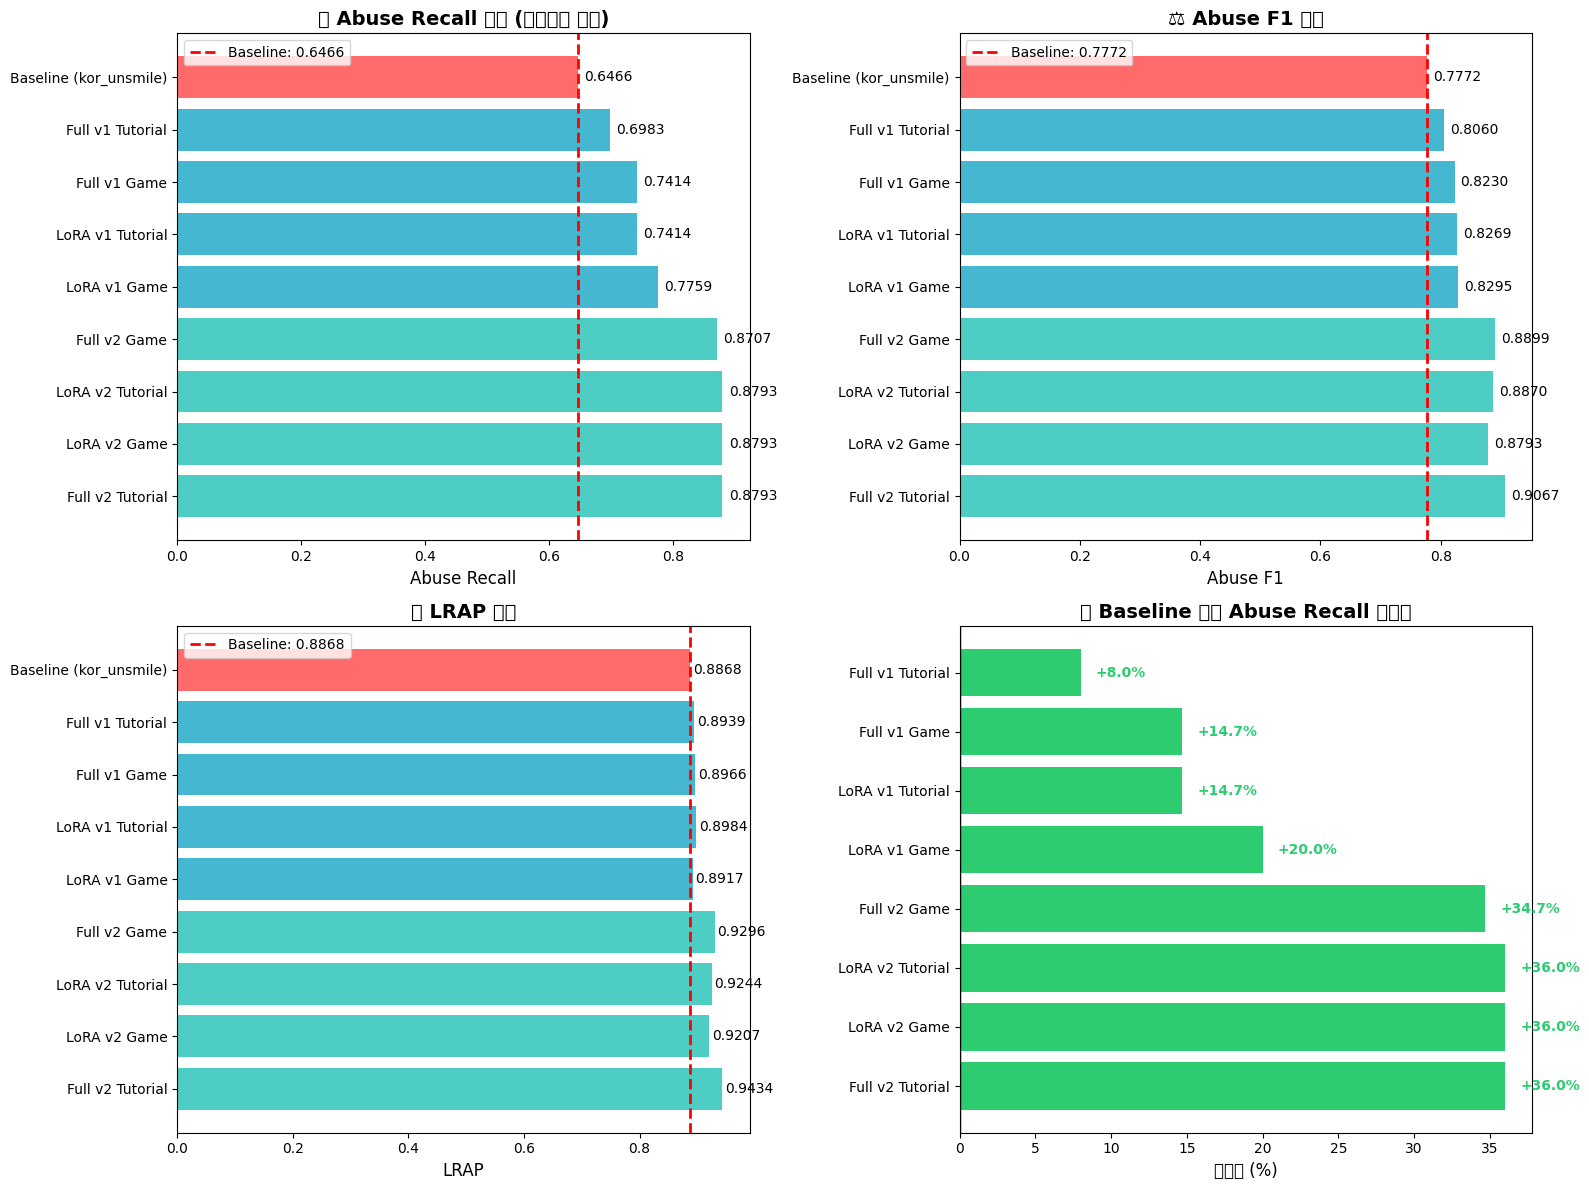

✅ 차트 저장: ./results/before_after_comparison.png


In [8]:
# 8. 시각화 - Before/After 비교 차트
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 색상 설정
colors = ['#FF6B6B' if 'Baseline' in m else '#4ECDC4' if 'v2' in m else '#45B7D1' 
          for m in results_df['model']]

# 1) Abuse Recall 비교
ax1 = axes[0, 0]
bars = ax1.barh(results_df['model'], results_df['abuse_recall'], color=colors)
ax1.axvline(x=baseline['abuse_recall'], color='red', linestyle='--', linewidth=2, label=f"Baseline: {baseline['abuse_recall']:.4f}")
ax1.set_xlabel('Abuse Recall', fontsize=12)
ax1.set_title('🎯 Abuse Recall 비교 (높을수록 좋음)', fontsize=14, fontweight='bold')
ax1.legend()
for bar, val in zip(bars, results_df['abuse_recall']):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10)

# 2) Abuse F1 비교
ax2 = axes[0, 1]
bars = ax2.barh(results_df['model'], results_df['abuse_f1'], color=colors)
ax2.axvline(x=baseline['abuse_f1'], color='red', linestyle='--', linewidth=2, label=f"Baseline: {baseline['abuse_f1']:.4f}")
ax2.set_xlabel('Abuse F1', fontsize=12)
ax2.set_title('⚖️ Abuse F1 비교', fontsize=14, fontweight='bold')
ax2.legend()
for bar, val in zip(bars, results_df['abuse_f1']):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10)

# 3) LRAP 비교
ax3 = axes[1, 0]
bars = ax3.barh(results_df['model'], results_df['lrap'], color=colors)
ax3.axvline(x=baseline['lrap'], color='red', linestyle='--', linewidth=2, label=f"Baseline: {baseline['lrap']:.4f}")
ax3.set_xlabel('LRAP', fontsize=12)
ax3.set_title('📊 LRAP 비교', fontsize=14, fontweight='bold')
ax3.legend()
for bar, val in zip(bars, results_df['lrap']):
    ax3.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10)

# 4) 개선율 비교
ax4 = axes[1, 1]
imp_df = improvement_df[~improvement_df['model'].str.contains('Baseline')].copy()
imp_colors = ['#2ECC71' if v > 0 else '#E74C3C' for v in imp_df['abuse_r_pct']]
bars = ax4.barh(imp_df['model'], imp_df['abuse_r_pct'], color=imp_colors)
ax4.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax4.set_xlabel('개선율 (%)', fontsize=12)
ax4.set_title('📈 Baseline 대비 Abuse Recall 개선율', fontsize=14, fontweight='bold')
for bar, val in zip(bars, imp_df['abuse_r_pct']):
    color = '#2ECC71' if val > 0 else '#E74C3C'
    ax4.text(val + (1 if val >= 0 else -3), bar.get_y() + bar.get_height()/2, 
             f'{val:+.1f}%', va='center', fontsize=10, color=color, fontweight='bold')

plt.tight_layout()
os.makedirs('./results', exist_ok=True)
plt.savefig('./results/before_after_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 차트 저장: ./results/before_after_comparison.png")

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

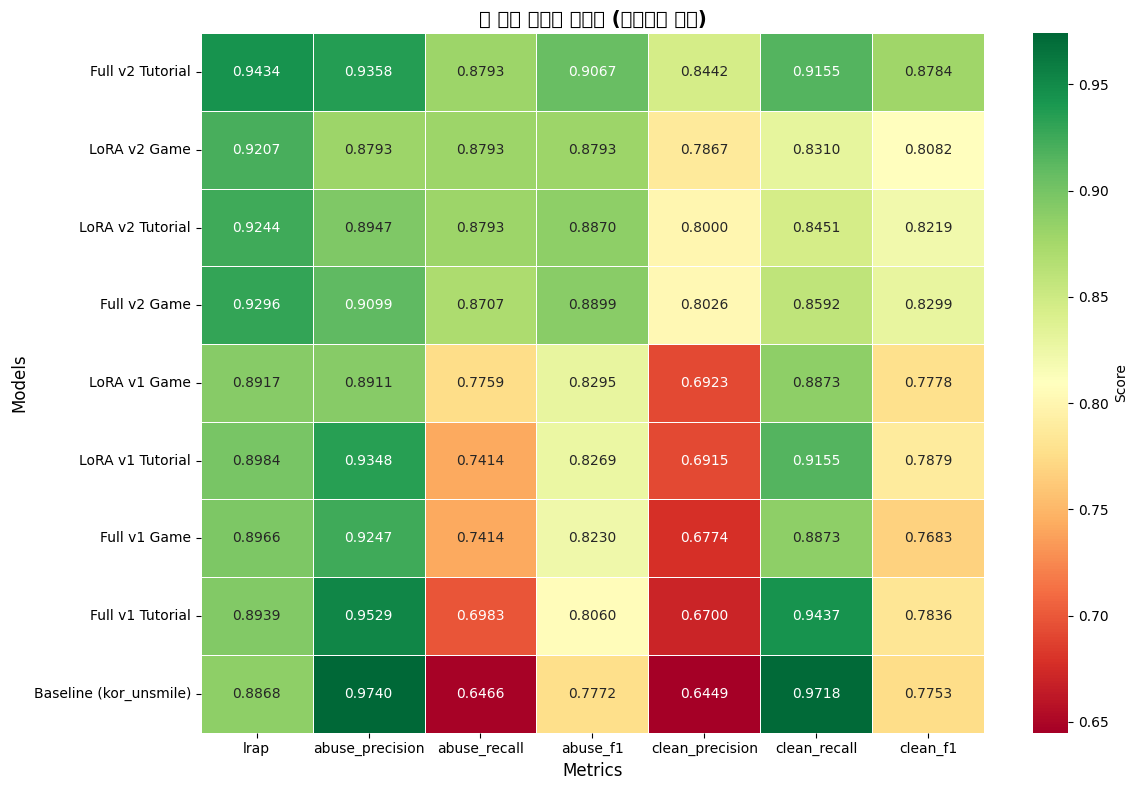

✅ 히트맵 저장: ./results/metrics_heatmap.png


In [9]:
# 9. 히트맵 - 전체 메트릭 비교
fig, ax = plt.subplots(figsize=(12, 8))

heatmap_df = results_df.set_index('model')[['lrap', 'abuse_precision', 'abuse_recall', 'abuse_f1', 
                                            'clean_precision', 'clean_recall', 'clean_f1']]

sns.heatmap(heatmap_df, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax, 
            linewidths=0.5, cbar_kws={'label': 'Score'})

ax.set_title('🔥 전체 메트릭 히트맵 (높을수록 녹색)', fontsize=14, fontweight='bold')
ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Models', fontsize=12)

plt.tight_layout()
plt.savefig('./results/metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 히트맵 저장: ./results/metrics_heatmap.png")

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

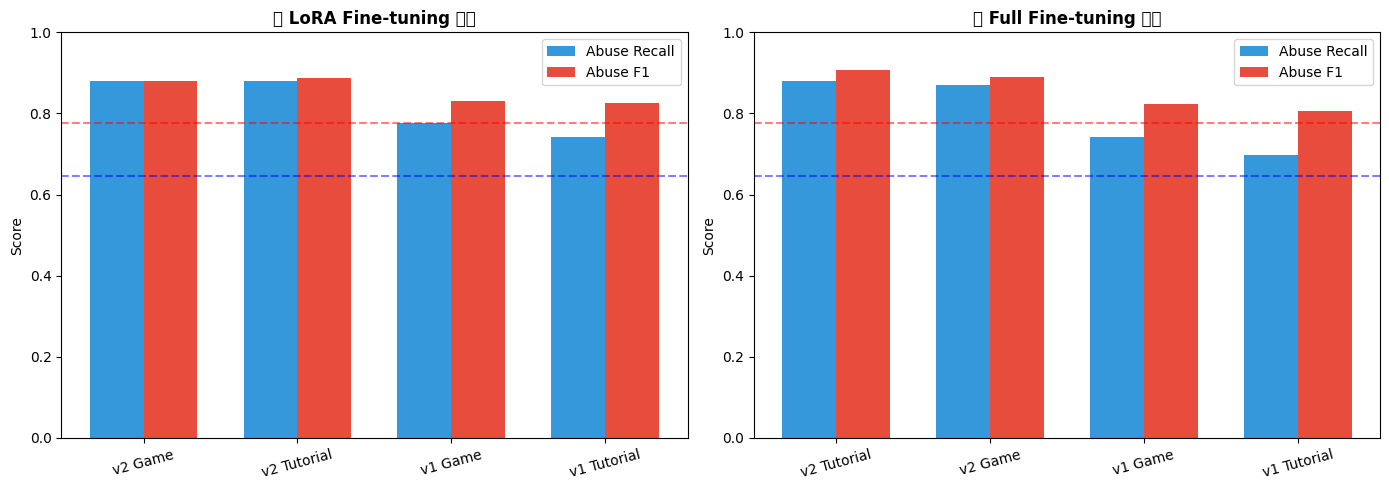

✅ 차트 저장: ./results/lora_vs_full.png


In [10]:
# 10. LoRA vs Full Fine-tuning 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 그룹별 분류
lora_models = results_df[results_df['model'].str.contains('LoRA')]
full_models = results_df[results_df['model'].str.contains('Full')]

# LoRA 결과
ax1 = axes[0]
x = range(len(lora_models))
width = 0.35
ax1.bar([i - width/2 for i in x], lora_models['abuse_recall'], width, label='Abuse Recall', color='#3498DB')
ax1.bar([i + width/2 for i in x], lora_models['abuse_f1'], width, label='Abuse F1', color='#E74C3C')
ax1.axhline(y=baseline['abuse_recall'], color='blue', linestyle='--', alpha=0.5)
ax1.axhline(y=baseline['abuse_f1'], color='red', linestyle='--', alpha=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels([m.replace('LoRA ', '') for m in lora_models['model']], rotation=15)
ax1.set_ylabel('Score')
ax1.set_title('📌 LoRA Fine-tuning 결과', fontsize=12, fontweight='bold')
ax1.legend()
ax1.set_ylim(0, 1)

# Full 결과
ax2 = axes[1]
x = range(len(full_models))
ax2.bar([i - width/2 for i in x], full_models['abuse_recall'], width, label='Abuse Recall', color='#3498DB')
ax2.bar([i + width/2 for i in x], full_models['abuse_f1'], width, label='Abuse F1', color='#E74C3C')
ax2.axhline(y=baseline['abuse_recall'], color='blue', linestyle='--', alpha=0.5)
ax2.axhline(y=baseline['abuse_f1'], color='red', linestyle='--', alpha=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels([m.replace('Full ', '') for m in full_models['model']], rotation=15)
ax2.set_ylabel('Score')
ax2.set_title('📌 Full Fine-tuning 결과', fontsize=12, fontweight='bold')
ax2.legend()
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('./results/lora_vs_full.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 차트 저장: ./results/lora_vs_full.png")

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

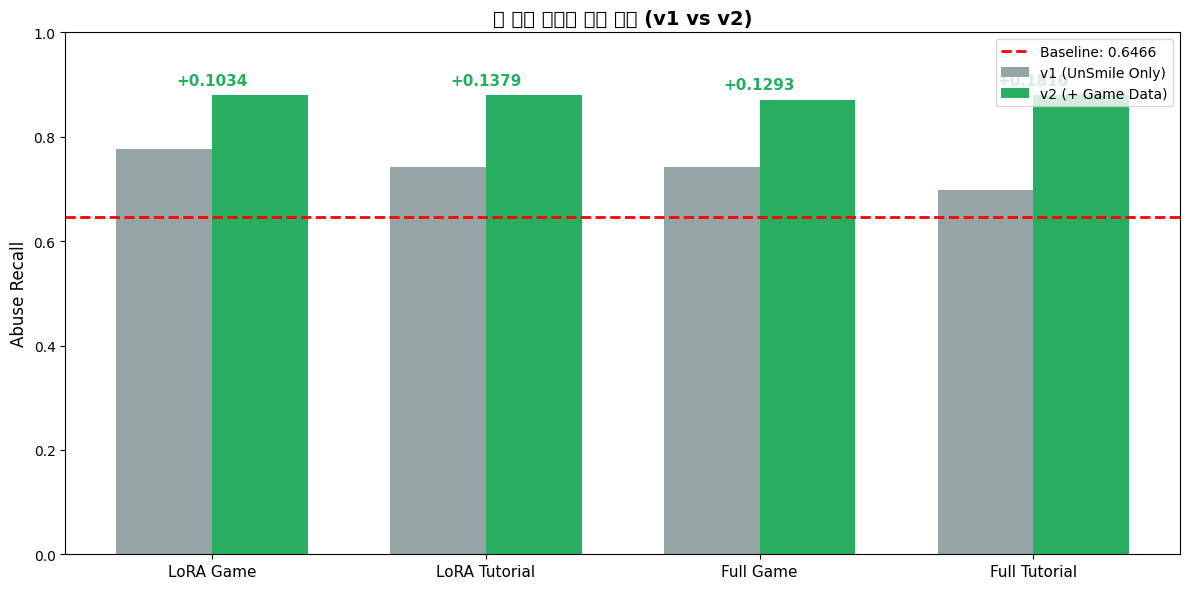

✅ 차트 저장: ./results/v1_vs_v2_comparison.png


In [11]:
# 11. v1 vs v2 비교 (게임 데이터 추가 효과)
fig, ax = plt.subplots(figsize=(12, 6))

# v1, v2 비교 데이터 구성
comparison = []
for method in ['LoRA', 'Full']:
    for base in ['Game', 'Tutorial']:
        v1_name = f"{method} v1 {base}"
        v2_name = f"{method} v2 {base}"
        
        v1_row = results_df[results_df['model'] == v1_name]
        v2_row = results_df[results_df['model'] == v2_name]
        
        if len(v1_row) > 0 and len(v2_row) > 0:
            comparison.append({
                'model': f"{method} {base}",
                'v1_recall': v1_row['abuse_recall'].values[0],
                'v2_recall': v2_row['abuse_recall'].values[0],
                'diff': v2_row['abuse_recall'].values[0] - v1_row['abuse_recall'].values[0]
            })

comp_df = pd.DataFrame(comparison)

x = range(len(comp_df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], comp_df['v1_recall'], width, label='v1 (UnSmile Only)', color='#95A5A6')
bars2 = ax.bar([i + width/2 for i in x], comp_df['v2_recall'], width, label='v2 (+ Game Data)', color='#27AE60')

ax.axhline(y=baseline['abuse_recall'], color='red', linestyle='--', linewidth=2, label=f"Baseline: {baseline['abuse_recall']:.4f}")

ax.set_xticks(x)
ax.set_xticklabels(comp_df['model'], fontsize=11)
ax.set_ylabel('Abuse Recall', fontsize=12)
ax.set_title('🎮 게임 데이터 추가 효과 (v1 vs v2)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim(0, 1)

# 차이값 표시
for i, row in comp_df.iterrows():
    diff = row['diff']
    color = '#27AE60' if diff > 0 else '#E74C3C'
    ax.annotate(f"{diff:+.4f}", 
                xy=(i, max(row['v1_recall'], row['v2_recall']) + 0.02),
                ha='center', fontsize=11, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig('./results/v1_vs_v2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 차트 저장: ./results/v1_vs_v2_comparison.png")

In [12]:
# 12. 결과 저장
results_df.to_csv('./results/game_test_results.csv', index=False)
improvement_df.to_csv('./results/improvement_analysis.csv', index=False)

print("✅ 결과 저장 완료:")
print("   - ./results/game_test_results.csv")
print("   - ./results/improvement_analysis.csv")
print("   - ./results/before_after_comparison.png")
print("   - ./results/metrics_heatmap.png")
print("   - ./results/lora_vs_full.png")
print("   - ./results/v1_vs_v2_comparison.png")

✅ 결과 저장 완료:
   - ./results/game_test_results.csv
   - ./results/improvement_analysis.csv
   - ./results/before_after_comparison.png
   - ./results/metrics_heatmap.png
   - ./results/lora_vs_full.png
   - ./results/v1_vs_v2_comparison.png


In [13]:
# 13. 최종 요약
print("="*60)
print("📊 최종 요약")
print("="*60)

best_model = results_df.iloc[0]
print(f"\n🏆 Best Model: {best_model['model']}")
print(f"   - Abuse Recall: {best_model['abuse_recall']:.4f}")
print(f"   - Abuse F1: {best_model['abuse_f1']:.4f}")
print(f"   - LRAP: {best_model['lrap']:.4f}")

print(f"\n📌 Baseline 대비 최고 개선율:")
best_imp = improvement_df[~improvement_df['model'].str.contains('Baseline')].sort_values('abuse_r_pct', ascending=False).iloc[0]
print(f"   {best_imp['model']}: {best_imp['abuse_r_pct']:+.1f}%")

print(f"\n📋 모든 모델 Abuse Recall:")
for _, row in results_df.iterrows():
    marker = '🥇' if row['model'] == best_model['model'] else '  '
    baseline_marker = '(Baseline)' if 'Baseline' in row['model'] else ''
    print(f"{marker} {row['model']}: {row['abuse_recall']:.4f} {baseline_marker}")

📊 최종 요약

🏆 Best Model: Full v2 Tutorial
   - Abuse Recall: 0.8793
   - Abuse F1: 0.9067
   - LRAP: 0.9434

📌 Baseline 대비 최고 개선율:
   Full v2 Tutorial: +36.0%

📋 모든 모델 Abuse Recall:
🥇 Full v2 Tutorial: 0.8793 
   LoRA v2 Game: 0.8793 
   LoRA v2 Tutorial: 0.8793 
   Full v2 Game: 0.8707 
   LoRA v1 Game: 0.7759 
   LoRA v1 Tutorial: 0.7414 
   Full v1 Game: 0.7414 
   Full v1 Tutorial: 0.6983 
   Baseline (kor_unsmile): 0.6466 (Baseline)
